## 1. Environment Setup and Data Loading

In [51]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os
import joblib

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, 
    precision_recall_curve, confusion_matrix, mean_squared_error,
    mean_absolute_error, r2_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTENC

# XGBoost
import xgboost as xgb

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Suppress warnings
warnings.filterwarnings('ignore')

# Create artifacts directory
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f"TensorFlow Version: {tf.__version__}")
print(f"XGBoost Version: {xgb.__version__}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")

TensorFlow Version: 2.20.0
XGBoost Version: 3.1.1
Artifacts directory: artifacts


In [52]:
# Load the dataset
DATA_PATH = 'preprocessed_data/timestamped_predictive_maintenance.csv'

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"\n{'='*80}")
print(f"DATASET OVERVIEW")
print(f"{'='*80}")
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\n{'='*80}")
print("First 5 rows:")
print(df.head())

print(f"\n{'='*80}")
print("Data Types:")
print(df.dtypes)

print(f"\n{'='*80}")
print("Statistical Summary:")
print(df.describe())

print(f"\n{'='*80}")
print("Missing Values:")
print(df.isnull().sum())

Loading dataset from: preprocessed_data/timestamped_predictive_maintenance.csv

DATASET OVERVIEW

Shape: 10,000 rows × 11 columns

First 5 rows:
   unit_id product_id engine_type  air_temp  process_temp   rpm  torque_nm  \
0       11     H29424           H     298.4         308.9  1782       23.9   
1       12     H29425           H     298.6         309.1  1423       44.3   
2       19     H29432           H     298.8         309.2  1306       54.5   
3       21     H29434           H     298.9         309.3  1375       42.7   
4       28     H29441           H     299.1         309.4  1811       24.6   

   tool_wear  target failure_type            timestamp  
0         24       0   No Failure  2024-01-11 16:00:00  
1         29       0   No Failure  2024-03-20 11:00:00  
2         50       0   No Failure  2024-02-22 17:00:00  
3         58       0   No Failure  2024-01-11 15:00:00  
4         77       0   No Failure  2024-01-25 07:00:00  

Data Types:
unit_id           int64
product

### Analyze Class Distribution

In [53]:
print(f"\n{'='*80}")
print("CLASS DISTRIBUTION")
print(f"{'='*80}")

print("\nFailure Type Distribution:")
failure_dist = df['failure_type'].value_counts()
print(failure_dist)
print(f"\nPercentages:")
print(df['failure_type'].value_counts(normalize=True) * 100)

# Calculate imbalance ratio
no_failure_count = failure_dist.iloc[0]
min_failure_count = failure_dist.iloc[-1]
imbalance_ratio = no_failure_count / min_failure_count
print(f"\nImbalance Ratio: {imbalance_ratio:.1f}:1")
print("⚠️ Extreme class imbalance detected - SMOTE-NC will be applied")


CLASS DISTRIBUTION

Failure Type Distribution:
failure_type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Percentages:
failure_type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64

Imbalance Ratio: 536.2:1
⚠️ Extreme class imbalance detected - SMOTE-NC will be applied


### 2. Preprocessing Pipeline

In [54]:
# Create binary target
df['is_failure'] = (df['failure_type'] != 'No Failure').astype(int)

print(f"Binary target 'is_failure' created:")
print(f"  0 (No Failure): {(df['is_failure'] == 0).sum():,}")
print(f"  1 (Failure): {(df['is_failure'] == 1).sum():,}")

# Label Encoding for categorical features
print(f"\n{'='*80}")
print("LABEL ENCODING")
print(f"{'='*80}")

# Initialize encoders
engine_encoder = LabelEncoder()
failure_encoder = LabelEncoder()

# Fit and transform
df['engine_type_encoded'] = engine_encoder.fit_transform(df['engine_type'])
df['failure_type_encoded'] = failure_encoder.fit_transform(df['failure_type'])

# Create mapping dictionaries
engine_mapping = dict(zip(engine_encoder.classes_, engine_encoder.transform(engine_encoder.classes_)))
failure_mapping = dict(zip(failure_encoder.classes_, failure_encoder.transform(failure_encoder.classes_)))

# Create reverse mappings for inference
engine_mapping_inv = {v: k for k, v in engine_mapping.items()}
failure_mapping_inv = {v: k for k, v in failure_mapping.items()}

print("\nEngine Type Mapping:")
for original, encoded in engine_mapping.items():
    print(f"  {original} → {encoded}")

print("\nFailure Type Mapping:")
for original, encoded in failure_mapping.items():
    print(f"  {original} → {encoded}")

# Save label mappings
label_mappings = {
    'engine_mapping': engine_mapping,
    'engine_mapping_inv': engine_mapping_inv,
    'failure_mapping': failure_mapping,
    'failure_mapping_inv': failure_mapping_inv
}
joblib.dump(label_mappings, ARTIFACTS_DIR / 'label_mappings.joblib')
print(f"\n✓ Label mappings saved to {ARTIFACTS_DIR / 'label_mappings.joblib'}")

Binary target 'is_failure' created:
  0 (No Failure): 9,652
  1 (Failure): 348

LABEL ENCODING

Engine Type Mapping:
  H → 0
  L → 1
  M → 2

Failure Type Mapping:
  Heat Dissipation Failure → 0
  No Failure → 1
  Overstrain Failure → 2
  Power Failure → 3
  Random Failures → 4
  Tool Wear Failure → 5

✓ Label mappings saved to artifacts\label_mappings.joblib


### Feature selection

In [55]:
print(f"\n{'='*80}")
print("TRAIN-TEST SPLIT")
print(f"{'='*80}")

# Define feature groups
NUMERICAL_FEATURES = ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']
CATEGORICAL_FEATURE = 'engine_type_encoded'

print(f"Numerical Features: {NUMERICAL_FEATURES}")
print(f"Categorical Feature: {CATEGORICAL_FEATURE}")

# Prepare feature matrix and targets
X = df[NUMERICAL_FEATURES + [CATEGORICAL_FEATURE]].copy()
y_multi = df['failure_type_encoded'].copy()  # Multi-class target
y_binary = df['is_failure'].copy()  # Binary target

# Split with stratification on failure_type
X_train, X_test, y_train_multi, y_test_multi, y_train_binary, y_test_binary = train_test_split(
    X, y_multi, y_binary,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_multi
)

print(f"\nTraining Set: {X_train.shape[0]:,} samples")
print(f"Test Set: {X_test.shape[0]:,} samples")
print(f"Split Ratio: {X_train.shape[0]/len(df)*100:.1f}% / {X_test.shape[0]/len(df)*100:.1f}%")

print(f"\nTraining Set Class Distribution:")
print(pd.Series(y_train_multi).map(failure_mapping_inv).value_counts())

print(f"\nTest Set Class Distribution:")
print(pd.Series(y_test_multi).map(failure_mapping_inv).value_counts())


TRAIN-TEST SPLIT
Numerical Features: ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']
Categorical Feature: engine_type_encoded

Training Set: 8,000 samples
Test Set: 2,000 samples
Split Ratio: 80.0% / 20.0%

Training Set Class Distribution:
failure_type_encoded
No Failure                  7722
Heat Dissipation Failure      90
Power Failure                 76
Overstrain Failure            62
Tool Wear Failure             36
Random Failures               14
Name: count, dtype: int64

Test Set Class Distribution:
failure_type_encoded
No Failure                  1930
Heat Dissipation Failure      22
Power Failure                 19
Overstrain Failure            16
Tool Wear Failure              9
Random Failures                4
Name: count, dtype: int64


### Normalization with StandardScaler

In [56]:
print(f"\n{'='*80}")
print("FEATURE NORMALIZATION")
print(f"{'='*80}")

# Initialize scaler
scaler = StandardScaler()

# Separate numerical and categorical features
X_train_num = X_train[NUMERICAL_FEATURES].copy()
X_test_num = X_test[NUMERICAL_FEATURES].copy()

X_train_cat = X_train[[CATEGORICAL_FEATURE]].copy()
X_test_cat = X_test[[CATEGORICAL_FEATURE]].copy()

# Fit scaler ONLY on training data
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)  # Transform only, no fitting

print(f"\n✓ StandardScaler fitted on training data")
print(f"  Mean: {scaler.mean_}")
print(f"  Std: {scaler.scale_}")

# Combine scaled numerical and categorical features
X_train_processed = np.hstack([X_train_num_scaled, X_train_cat.values])
X_test_processed = np.hstack([X_test_num_scaled, X_test_cat.values])

print(f"\n✓ Processed Training Shape: {X_train_processed.shape}")
print(f"✓ Processed Test Shape: {X_test_processed.shape}")

# Save scaler
joblib.dump(scaler, ARTIFACTS_DIR / 'scaler.joblib')
print(f"\n✓ Scaler saved to {ARTIFACTS_DIR / 'scaler.joblib'}")

# %%
# Apply SMOTE-NC for class balancing (training only)
print(f"\n{'='*80}")
print("CLASS BALANCING WITH SMOTE-NC")
print(f"{'='*80}")

# Identify categorical feature index (last column)
categorical_feature_index = [len(NUMERICAL_FEATURES)]  # Index 5 (0-indexed)

print(f"\nCategorical feature index: {categorical_feature_index}")
print(f"Applying SMOTE-NC to training data only...")

# Initialize SMOTE-NC
smote_nc = SMOTENC(
    categorical_features=categorical_feature_index,
    random_state=RANDOM_SEED,
    k_neighbors=5
)


FEATURE NORMALIZATION

✓ StandardScaler fitted on training data
  Mean: [ 300.01175    310.0075125 1539.682125    39.935925   107.520875 ]
  Std: [  1.99884828   1.48629399 180.04973155   9.95493631  63.60652533]

✓ Processed Training Shape: (8000, 6)
✓ Processed Test Shape: (2000, 6)

✓ Scaler saved to artifacts\scaler.joblib

CLASS BALANCING WITH SMOTE-NC

Categorical feature index: [5]
Applying SMOTE-NC to training data only...


### Apply SMOTE-NC to training data

In [57]:
X_train_balanced, y_train_balanced = smote_nc.fit_resample(X_train_processed, y_train_multi)

print(f"\n✓ SMOTE-NC Applied:")
print(f"  Original Training Size: {X_train_processed.shape[0]:,}")
print(f"  Balanced Training Size: {X_train_balanced.shape[0]:,}")

print(f"\nBalanced Class Distribution:")
balanced_dist = pd.Series(y_train_balanced).map(failure_mapping_inv).value_counts()
print(balanced_dist)

print(f"\n⚠️ Test data remains UNCHANGED (original distribution)")


✓ SMOTE-NC Applied:
  Original Training Size: 8,000
  Balanced Training Size: 46,332

Balanced Class Distribution:
failure_type_encoded
No Failure                  7722
Tool Wear Failure           7722
Random Failures             7722
Power Failure               7722
Heat Dissipation Failure    7722
Overstrain Failure          7722
Name: count, dtype: int64

⚠️ Test data remains UNCHANGED (original distribution)


### 3. Time-Series / Sequence Preparation

In [58]:
# Sort data by timestamp
print(f"\n{'='*80}")
print("TIME-SERIES PREPARATION")
print(f"{'='*80}")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by timestamp
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

print(f"\n✓ Data sorted by timestamp")
print(f"  Earliest: {df_sorted['timestamp'].min()}")
print(f"  Latest: {df_sorted['timestamp'].max()}")
print(f"  Duration: {(df_sorted['timestamp'].max() - df_sorted['timestamp'].min()).days} days")

# %%
# Create lag features
print(f"\n{'='*80}")
print("LAG FEATURE ENGINEERING")
print(f"{'='*80}")

LAG_PERIODS = [1, 3, 5]

for feature in NUMERICAL_FEATURES:
    for lag in LAG_PERIODS:
        df_sorted[f'{feature}_lag{lag}'] = df_sorted[feature].shift(lag)

# Drop rows with NaN from lagging
df_sorted = df_sorted.dropna().reset_index(drop=True)

print(f"\n✓ Created lag features for periods: {LAG_PERIODS}")
print(f"  Rows after dropping NaN: {len(df_sorted):,}")

lag_features = [col for col in df_sorted.columns if 'lag' in col]
print(f"  Total lag features created: {len(lag_features)}")


TIME-SERIES PREPARATION

✓ Data sorted by timestamp
  Earliest: 2024-01-01 06:00:00
  Latest: 2024-04-30 18:00:00
  Duration: 120 days

LAG FEATURE ENGINEERING

✓ Created lag features for periods: [1, 3, 5]
  Rows after dropping NaN: 9,995
  Total lag features created: 15


### Generate RUL (Remaining Useful Life) proxy

In [59]:
print(f"\n{'='*80}")
print("RUL (REMAINING USEFUL LIFE) PROXY GENERATION")
print(f"{'='*80}")

def generate_rul_proxy(row):
    """
    Generate RUL based ONLY on sensor readings (no target leakage).
    
    Strategy:
    - Calculate stress indicators from sensor deviations
    - Higher stress = lower RUL
    - Add realistic noise
    """
    # Baseline values (normal operating conditions)
    BASELINE_AIR_TEMP = 295
    BASELINE_RPM = 1500
    BASELINE_TORQUE = 40
    MAX_TOOL_WEAR = 200
    
    # Calculate stress indicators (0-1 scale)
    temp_stress = abs(row['air_temp'] - BASELINE_AIR_TEMP) / 10
    rpm_stress = abs(row['rpm'] - BASELINE_RPM) / 1000
    torque_stress = abs(row['torque_nm'] - BASELINE_TORQUE) / 20
    wear_factor = row['tool_wear'] / MAX_TOOL_WEAR
    
    # Combined stress (higher = worse condition)
    total_stress = (temp_stress + rpm_stress + torque_stress + wear_factor) / 4
    total_stress = np.clip(total_stress, 0, 1)
    
    # RUL calculation: inverse relationship with stress
    BASE_RUL = 180  # days
    rul = BASE_RUL * (1 - total_stress)
    
    # Add realistic noise
    rul += np.random.normal(0, 5)
    rul = np.clip(rul, 10, 200)
    
    return rul

# Apply RUL generation
print("\nGenerating RUL proxy for all samples...")
df_sorted['rul_proxy'] = df_sorted.apply(generate_rul_proxy, axis=1)

print(f"\n✓ RUL Proxy Statistics:")
print(df_sorted['rul_proxy'].describe())

print(f"\n⚠️ Important: RUL is calculated ONLY from sensor readings")
print(f"   (No data leakage from failure_type target)")

# %%
# Create sequences for LSTM
print(f"\n{'='*80}")
print("SEQUENCE GENERATION FOR LSTM")
print(f"{'='*80}")

WINDOW_SIZE = 10  # Number of timesteps in each sequence

def create_sequences(X, y, window_size=10):
    """
    Create overlapping sequences for LSTM input.
    
    Args:
        X: Feature array
        y: Target array
        window_size: Number of timesteps per sequence
    
    Returns:
        X_seq: 3D array (samples, timesteps, features)
        y_seq: Target for each sequence (label at last timestep)
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - window_size + 1):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size-1])  # Label is last timestep
    
    return np.array(X_seq), np.array(y_seq)

print(f"\nWindow Size: {WINDOW_SIZE} timesteps")
print(f"Sequence Strategy: Overlapping windows with label at last timestep")

# Prepare features for sequencing
seq_features = NUMERICAL_FEATURES + [CATEGORICAL_FEATURE]
X_seq_data = df_sorted[seq_features].values
y_seq_clf = df_sorted['failure_type_encoded'].values
y_seq_reg = df_sorted['rul_proxy'].values

# Get train/test indices from sorted data
train_size = int(0.8 * len(df_sorted))

X_seq_train_data = X_seq_data[:train_size]
X_seq_test_data = X_seq_data[train_size:]

y_seq_train_clf = y_seq_clf[:train_size]
y_seq_test_clf = y_seq_clf[train_size:]

y_seq_train_reg = y_seq_reg[:train_size]
y_seq_test_reg = y_seq_reg[train_size:]

# Scale numerical features for sequences
scaler_seq = StandardScaler()
X_seq_train_num = X_seq_train_data[:, :len(NUMERICAL_FEATURES)]
X_seq_test_num = X_seq_test_data[:, :len(NUMERICAL_FEATURES)]

X_seq_train_num_scaled = scaler_seq.fit_transform(X_seq_train_num)
X_seq_test_num_scaled = scaler_seq.transform(X_seq_test_num)

# Combine scaled numerical and categorical
X_seq_train_scaled = np.hstack([
    X_seq_train_num_scaled, 
    X_seq_train_data[:, len(NUMERICAL_FEATURES):]
])
X_seq_test_scaled = np.hstack([
    X_seq_test_num_scaled,
    X_seq_test_data[:, len(NUMERICAL_FEATURES):]
])

# Create sequences respecting train/test split
X_train_seq_clf, y_train_seq_clf = create_sequences(
    X_seq_train_scaled, y_seq_train_clf, WINDOW_SIZE
)
X_test_seq_clf, y_test_seq_clf = create_sequences(
    X_seq_test_scaled, y_seq_test_clf, WINDOW_SIZE
)

X_train_seq_reg, y_train_seq_reg = create_sequences(
    X_seq_train_scaled, y_seq_train_reg, WINDOW_SIZE
)
X_test_seq_reg, y_test_seq_reg = create_sequences(
    X_seq_test_scaled, y_seq_train_reg, WINDOW_SIZE
)

print(f"\n✓ Sequences Created:")
print(f"  Training Classification: {X_train_seq_clf.shape}")
print(f"  Test Classification: {X_test_seq_clf.shape}")
print(f"  Training Regression: {X_train_seq_reg.shape}")
print(f"  Test Regression: {X_test_seq_reg.shape}")

print(f"\n⚠️ Sequence generation respects train/test boundary")
print(f"   (No future information leakage)")


RUL (REMAINING USEFUL LIFE) PROXY GENERATION

Generating RUL proxy for all samples...

✓ RUL Proxy Statistics:
count    9995.000000
mean      109.666789
std        25.624238
min        10.000000
25%        94.143901
50%       111.530489
75%       127.851932
max       175.480012
Name: rul_proxy, dtype: float64

⚠️ Important: RUL is calculated ONLY from sensor readings
   (No data leakage from failure_type target)

SEQUENCE GENERATION FOR LSTM

Window Size: 10 timesteps
Sequence Strategy: Overlapping windows with label at last timestep

✓ Sequences Created:
  Training Classification: (7987, 10, 6)
  Test Classification: (1990, 10, 6)
  Training Regression: (7987, 10, 6)
  Test Regression: (1990, 10, 6)

⚠️ Sequence generation respects train/test boundary
   (No future information leakage)

✓ RUL Proxy Statistics:
count    9995.000000
mean      109.666789
std        25.624238
min        10.000000
25%        94.143901
50%       111.530489
75%       127.851932
max       175.480012
Name: ru

### 4. Experiment 1 - XGBoost


XGBOOST CLASSIFICATION - ANOMALY DETECTION

Training XGBoost Classifier...
✓ Training completed

XGBoost Classification Metrics

Accuracy (ACC): 0.9450 ✓
Precision (PREC): 0.9782
Recall (REC): 0.9450 ✓
F1-Score (F1): 0.9610
ROC-AUC: 0.9215
PR-AUC: 0.9990

✓ Metrics saved to artifacts\xgb_clf_metrics.txt
✓ Training completed

XGBoost Classification Metrics

Accuracy (ACC): 0.9450 ✓
Precision (PREC): 0.9782
Recall (REC): 0.9450 ✓
F1-Score (F1): 0.9610
ROC-AUC: 0.9215
PR-AUC: 0.9990

✓ Metrics saved to artifacts\xgb_clf_metrics.txt


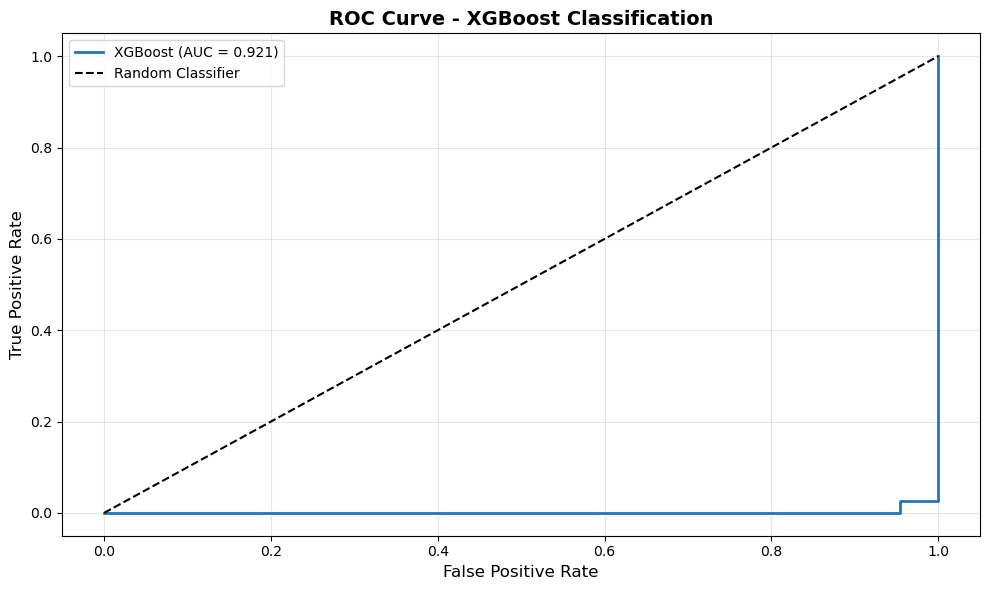

✓ ROC curve saved to artifacts\roc_curve_xgb.png


In [60]:
print(f"\n{'='*80}")
print("XGBOOST CLASSIFICATION - ANOMALY DETECTION")
print(f"{'='*80}")

# Train XGBoost classifier on SMOTE-balanced data
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train_multi)),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    random_state=RANDOM_SEED,
    eval_metric='mlogloss'
)

print("\nTraining XGBoost Classifier...")
xgb_clf.fit(X_train_balanced, y_train_balanced)
print("✓ Training completed")

# Predictions on original test set
y_pred_xgb_clf = xgb_clf.predict(X_test_processed)
y_pred_proba_xgb_clf = xgb_clf.predict_proba(X_test_processed)

# %%
# Calculate classification metrics
print(f"\n{'='*80}")
print("XGBoost Classification Metrics")
print(f"{'='*80}")

acc_xgb_clf = accuracy_score(y_test_multi, y_pred_xgb_clf)
prec_xgb_clf = precision_score(y_test_multi, y_pred_xgb_clf, average='weighted', zero_division=0)
rec_xgb_clf = recall_score(y_test_multi, y_pred_xgb_clf, average='weighted')
f1_xgb_clf = f1_score(y_test_multi, y_pred_xgb_clf, average='weighted')
roc_auc_xgb_clf = roc_auc_score(y_test_multi, y_pred_proba_xgb_clf, 
                                  multi_class='ovr', average='weighted')

# For binary (failure vs no failure) metrics
y_test_binary_xgb = (y_test_multi != 0).astype(int)
y_pred_binary_xgb = (y_pred_xgb_clf != 0).astype(int)
pr_auc_xgb_clf = average_precision_score(y_test_binary_xgb, y_pred_binary_xgb)

print(f"\nAccuracy (ACC): {acc_xgb_clf:.4f} {'✓' if acc_xgb_clf > 0.70 else '✗'}")
print(f"Precision (PREC): {prec_xgb_clf:.4f}")
print(f"Recall (REC): {rec_xgb_clf:.4f} {'✓' if rec_xgb_clf > 0.70 else '✗'}")
print(f"F1-Score (F1): {f1_xgb_clf:.4f}")
print(f"ROC-AUC: {roc_auc_xgb_clf:.4f}")
print(f"PR-AUC: {pr_auc_xgb_clf:.4f}")

# Save metrics to file
xgb_clf_metrics_text = f"""XGBoost Classification Metrics
{'='*50}

Accuracy (ACC): {acc_xgb_clf:.4f}
Precision (PREC): {prec_xgb_clf:.4f}
Recall (REC): {rec_xgb_clf:.4f}
F1-Score (F1): {f1_xgb_clf:.4f}
ROC-AUC (weighted): {roc_auc_xgb_clf:.4f}
PR-AUC (binary): {pr_auc_xgb_clf:.4f}

Target Achievement:
- Recall > 70%: {'PASS' if rec_xgb_clf > 0.70 else 'FAIL'}
- Accuracy > 70%: {'PASS' if acc_xgb_clf > 0.70 else 'FAIL'}
"""

with open(ARTIFACTS_DIR / 'xgb_clf_metrics.txt', 'w') as f:
    f.write(xgb_clf_metrics_text)

print(f"\n✓ Metrics saved to {ARTIFACTS_DIR / 'xgb_clf_metrics.txt'}")

# %%
# Plot ROC Curve
plt.figure(figsize=(10, 6))

# For multi-class, plot ROC for "failure" (any failure) vs "no failure"
fpr, tpr, _ = roc_curve(y_test_binary_xgb, y_pred_proba_xgb_clf[:, 0])
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_xgb_clf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - XGBoost Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'roc_curve_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved to {ARTIFACTS_DIR / 'roc_curve_xgb.png'}")


### Plot Precision-Recall Curve

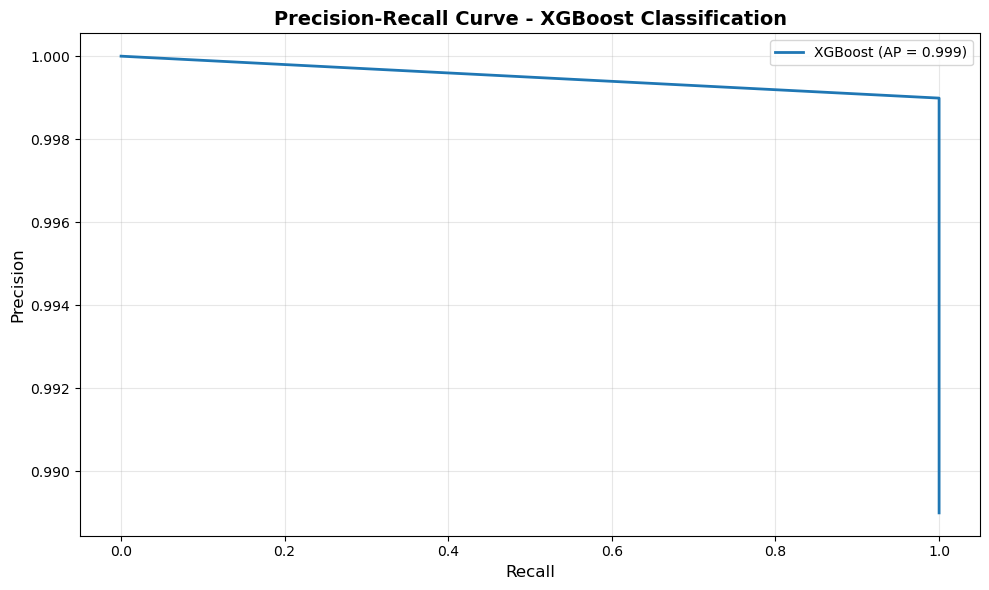

✓ PR curve saved to artifacts\pr_curve_xgb.png


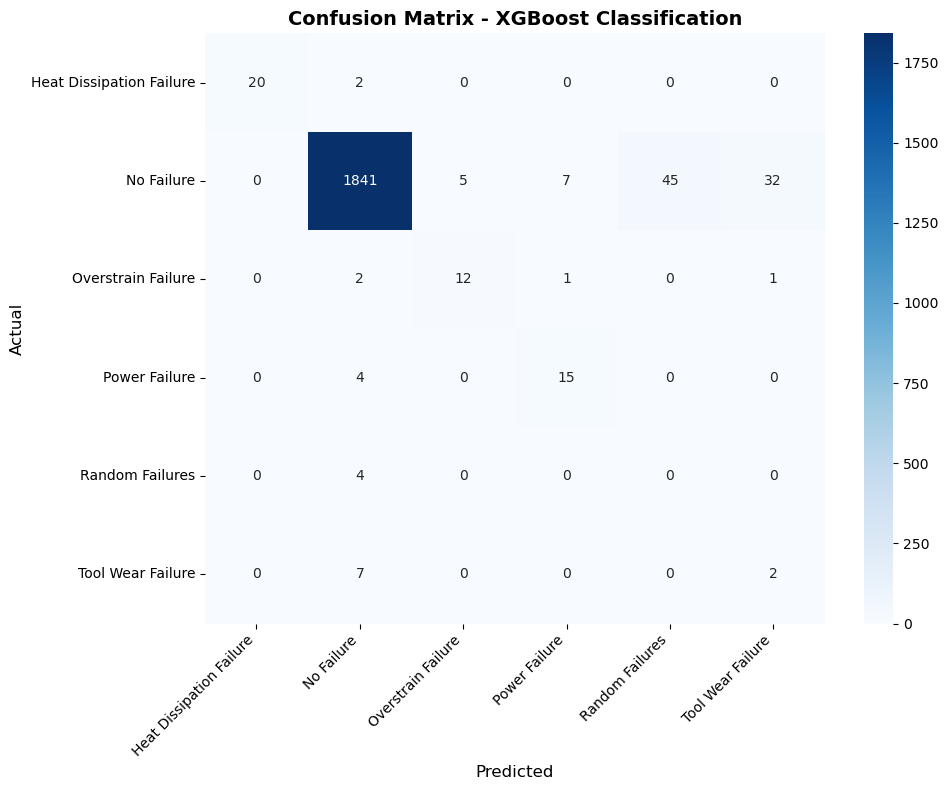

✓ Confusion matrix saved to artifacts\confusion_matrix_xgb.png


In [61]:
plt.figure(figsize=(10, 6))

precision, recall, _ = precision_recall_curve(y_test_binary_xgb, y_pred_binary_xgb)
plt.plot(recall, precision, label=f'XGBoost (AP = {pr_auc_xgb_clf:.3f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - XGBoost Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'pr_curve_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ PR curve saved to {ARTIFACTS_DIR / 'pr_curve_xgb.png'}")

# %%
# Plot Confusion Matrix
cm_xgb_clf = confusion_matrix(y_test_multi, y_pred_xgb_clf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb_clf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[failure_mapping_inv[i] for i in range(len(cm_xgb_clf))],
            yticklabels=[failure_mapping_inv[i] for i in range(len(cm_xgb_clf))])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost Classification', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'confusion_matrix_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved to {ARTIFACTS_DIR / 'confusion_matrix_xgb.png'}")

### Save XGBoost classifier

In [62]:
xgb_clf.save_model(str(ARTIFACTS_DIR / 'xgb_classifier.json'))
print(f"\n✓ XGBoost classifier saved to {ARTIFACTS_DIR / 'xgb_classifier.json'}")


✓ XGBoost classifier saved to artifacts\xgb_classifier.json


### 4.2 XGBoost Regression (Time-Series Forecasting)

In [63]:
print(f"\n{'='*80}")
print("XGBOOST REGRESSION - RUL FORECASTING")
print(f"{'='*80}")

# Prepare regression data with RUL target
# Add classification probabilities as features
train_indices = df_sorted.index[:train_size]
test_indices = df_sorted.index[train_size:]

# Get RUL target
y_train_reg = df_sorted.loc[train_indices, 'rul_proxy'].values
y_test_reg = df_sorted.loc[test_indices, 'rul_proxy'].values

# Prepare features: numerical + lag features + categorical
reg_features = NUMERICAL_FEATURES + lag_features + [CATEGORICAL_FEATURE]
X_train_reg = df_sorted.loc[train_indices, reg_features].values
X_test_reg = df_sorted.loc[test_indices, reg_features].values

# Scale features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Train XGBoost regressor
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    random_state=RANDOM_SEED
)

print("\nTraining XGBoost Regressor...")
xgb_reg.fit(X_train_reg_scaled, y_train_reg)
print("✓ Training completed")

# Predictions
y_pred_xgb_reg = xgb_reg.predict(X_test_reg_scaled)

# %%
# Calculate regression metrics
print(f"\n{'='*80}")
print("XGBoost Regression Metrics")
print(f"{'='*80}")

rmse_xgb_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
mae_xgb_reg = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
mse_xgb_reg = mean_squared_error(y_test_reg, y_pred_xgb_reg)
r2_xgb_reg = r2_score(y_test_reg, y_pred_xgb_reg)

print(f"\nRMSE: {rmse_xgb_reg:.4f} days {'✓' if rmse_xgb_reg < 30 else '✗'}")
print(f"MAE: {mae_xgb_reg:.4f} days {'✓' if mae_xgb_reg < 20 else '✗'}")
print(f"MSE: {mse_xgb_reg:.4f}")
print(f"R²: {r2_xgb_reg:.4f}")

# Save metrics
xgb_reg_metrics_text = f"""XGBoost Regression Metrics
{'='*50}

RMSE: {rmse_xgb_reg:.4f} days
MAE: {mae_xgb_reg:.4f} days
MSE: {mse_xgb_reg:.4f}
R²: {r2_xgb_reg:.4f}

Target Achievement:
- RMSE < 30 days: {'PASS' if rmse_xgb_reg < 30 else 'FAIL'}
- MAE < 20 days: {'PASS' if mae_xgb_reg < 20 else 'FAIL'}
"""

with open(ARTIFACTS_DIR / 'xgb_reg_metrics.txt', 'w') as f:
    f.write(xgb_reg_metrics_text)

print(f"\n✓ Metrics saved to {ARTIFACTS_DIR / 'xgb_reg_metrics.txt'}")


XGBOOST REGRESSION - RUL FORECASTING

Training XGBoost Regressor...
✓ Training completed

XGBoost Regression Metrics

RMSE: 5.5222 days ✓
MAE: 4.3370 days ✓
MSE: 30.4951
R²: 0.9539

✓ Metrics saved to artifacts\xgb_reg_metrics.txt
✓ Training completed

XGBoost Regression Metrics

RMSE: 5.5222 days ✓
MAE: 4.3370 days ✓
MSE: 30.4951
R²: 0.9539

✓ Metrics saved to artifacts\xgb_reg_metrics.txt


### Plot Predicted vs Actual

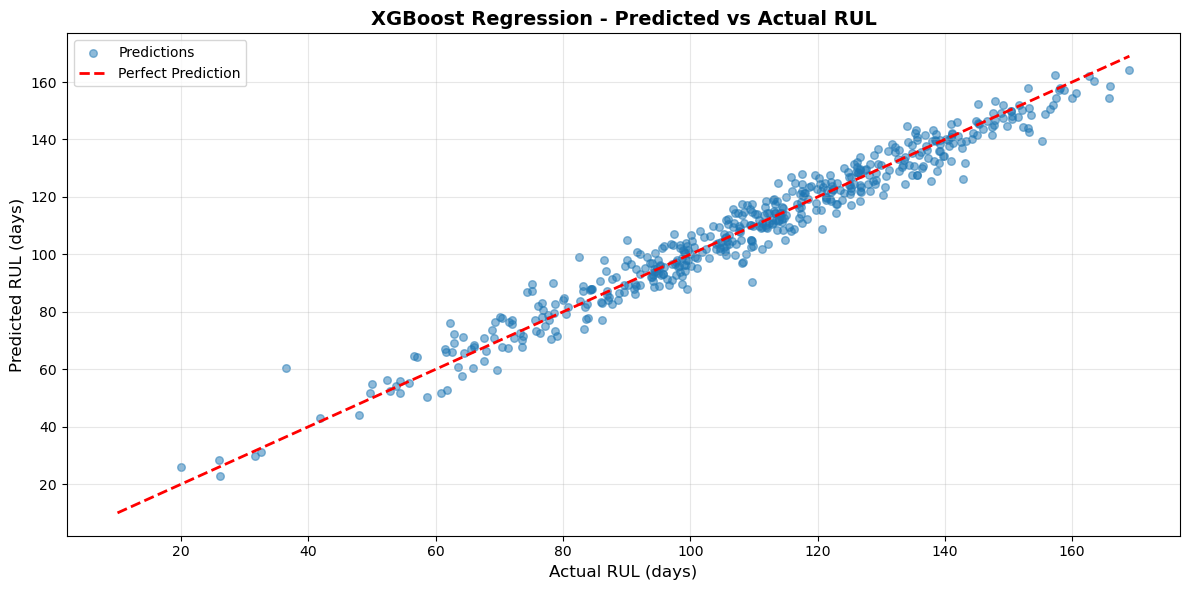

✓ Prediction plot saved to artifacts\predicted_vs_actual_xgb.png


In [64]:
plt.figure(figsize=(12, 6))

# Sample 500 points for clarity
sample_size = min(500, len(y_test_reg))
sample_indices = np.random.choice(len(y_test_reg), sample_size, replace=False)

plt.scatter(y_test_reg[sample_indices], y_pred_xgb_reg[sample_indices], 
            alpha=0.5, s=30, label='Predictions')
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual RUL (days)', fontsize=12)
plt.ylabel('Predicted RUL (days)', fontsize=12)
plt.title('XGBoost Regression - Predicted vs Actual RUL', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'predicted_vs_actual_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Prediction plot saved to {ARTIFACTS_DIR / 'predicted_vs_actual_xgb.png'}")# Save XGBoost regressor

### Save XGBoost regressor

In [65]:
xgb_reg.save_model(str(ARTIFACTS_DIR / 'xgb_regressor.json'))
print(f"\n✓ XGBoost regressor saved to {ARTIFACTS_DIR / 'xgb_regressor.json'}")


✓ XGBoost regressor saved to artifacts\xgb_regressor.json


### 5. Experiment 2 - LSTM

### 5.1 LSTM Classification (Anomaly Detection)

In [66]:
print(f"\n{'='*80}")
print("LSTM CLASSIFICATION - SEQUENCE-BASED ANOMALY DETECTION")
print(f"{'='*80}")

# Build LSTM architecture
n_features = X_train_seq_clf.shape[2]
n_classes = len(np.unique(y_train_multi))

lstm_clf_model = keras.Sequential([
    layers.LSTM(64, activation='relu', return_sequences=True, 
                input_shape=(WINDOW_SIZE, n_features)),
    layers.Dropout(0.3),
    layers.LSTM(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
], name='LSTM_Classifier')

lstm_clf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*80)
print("LSTM Classification Architecture")
print("="*80)
lstm_clf_model.summary()

# %%
# Train LSTM classifier
print(f"\n{'='*80}")
print("Training LSTM Classifier...")
print(f"{'='*80}")

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_lstm_clf = lstm_clf_model.fit(
    X_train_seq_clf, y_train_seq_clf,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ Training completed")

# %%
# Predictions
y_pred_lstm_clf = lstm_clf_model.predict(X_test_seq_clf)
y_pred_lstm_clf_classes = np.argmax(y_pred_lstm_clf, axis=1)

# %%
# Calculate classification metrics
print(f"\n{'='*80}")
print("LSTM Classification Metrics")
print(f"{'='*80}")

acc_lstm_clf = accuracy_score(y_test_seq_clf, y_pred_lstm_clf_classes)
prec_lstm_clf = precision_score(y_test_seq_clf, y_pred_lstm_clf_classes, 
                                  average='weighted', zero_division=0)
rec_lstm_clf = recall_score(y_test_seq_clf, y_pred_lstm_clf_classes, average='weighted')
f1_lstm_clf = f1_score(y_test_seq_clf, y_pred_lstm_clf_classes, average='weighted')
roc_auc_lstm_clf = roc_auc_score(y_test_seq_clf, y_pred_lstm_clf, 
                                   multi_class='ovr', average='weighted')

# Binary metrics
y_test_binary_lstm = (y_test_seq_clf != 0).astype(int)
y_pred_binary_lstm = (y_pred_lstm_clf_classes != 0).astype(int)
pr_auc_lstm_clf = average_precision_score(y_test_binary_lstm, y_pred_binary_lstm)

print(f"\nAccuracy (ACC): {acc_lstm_clf:.4f} {'✓' if acc_lstm_clf > 0.70 else '✗'}")
print(f"Precision (PREC): {prec_lstm_clf:.4f}")
print(f"Recall (REC): {rec_lstm_clf:.4f} {'✓' if rec_lstm_clf > 0.70 else '✗'}")
print(f"F1-Score (F1): {f1_lstm_clf:.4f}")
print(f"ROC-AUC: {roc_auc_lstm_clf:.4f}")
print(f"PR-AUC: {pr_auc_lstm_clf:.4f}")

# Save metrics
lstm_clf_metrics_text = f"""LSTM Classification Metrics
{'='*50}

Accuracy (ACC): {acc_lstm_clf:.4f}
Precision (PREC): {prec_lstm_clf:.4f}
Recall (REC): {rec_lstm_clf:.4f}
F1-Score (F1): {f1_lstm_clf:.4f}
ROC-AUC (weighted): {roc_auc_lstm_clf:.4f}
PR-AUC (binary): {pr_auc_lstm_clf:.4f}

Target Achievement:
- Recall > 70%: {'PASS' if rec_lstm_clf > 0.70 else 'FAIL'}
- Accuracy > 70%: {'PASS' if acc_lstm_clf > 0.70 else 'FAIL'}
"""

with open(ARTIFACTS_DIR / 'lstm_clf_metrics.txt', 'w') as f:
    f.write(lstm_clf_metrics_text)

print(f"\n✓ Metrics saved to {ARTIFACTS_DIR / 'lstm_clf_metrics.txt'}")


LSTM CLASSIFICATION - SEQUENCE-BASED ANOMALY DETECTION

LSTM Classification Architecture


Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,846 (124.40 KB)

 Trainable params: 31,846 (124.40 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Classifier...
Epoch 1/50
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9394 - loss: 0.4130 - val_accuracy: 0.9662 - val_loss: 0.2115
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9394 - loss: 0.4130 - val_accuracy: 0.9662 - val_loss: 0.2115
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9642 - loss: 0.2253 - val_accuracy: 0.9662 - val_loss: 0.1992
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9642 - loss: 0.2253 - val_accuracy: 0.9662 - val_loss: 0.1992
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9642 - loss: 0.2132 - val_accuracy: 0.9662 - val_loss: 0.1935
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9642 - loss: 0.2132 - val_accuracy: 0.9662 - val_loss: 0.1935
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9642 - loss: 0.1966 - val_accuracy: 0.9662 - val_loss: 0.1844
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 

### Plot ROC Curve

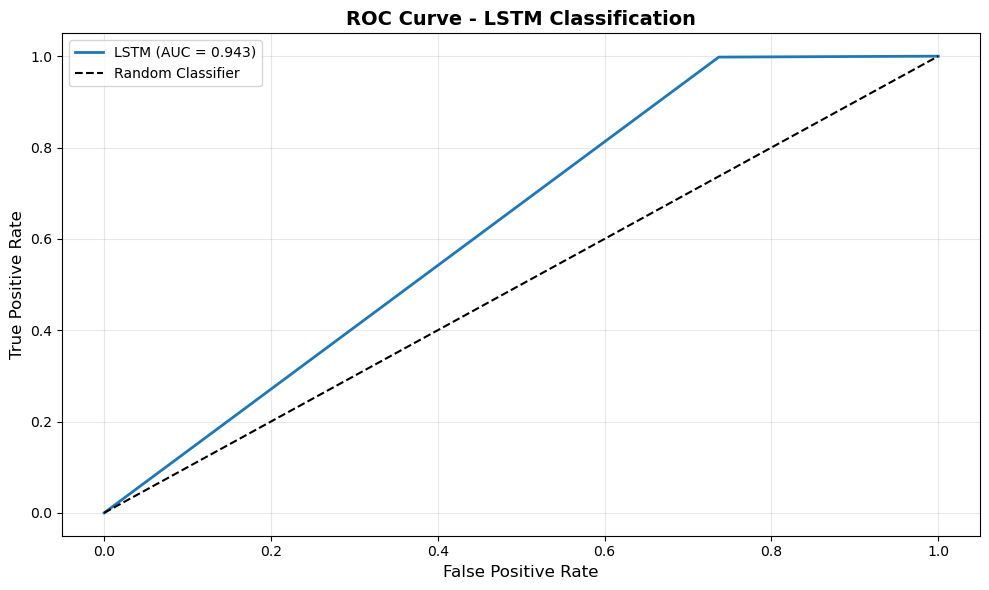

✓ ROC curve saved to artifacts\roc_curve_lstm.png


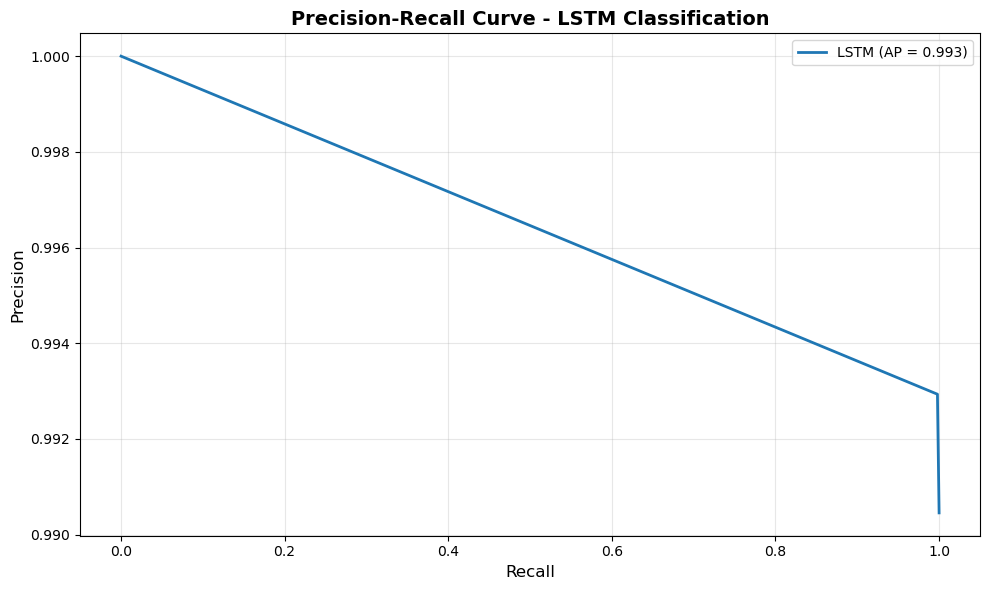

✓ PR curve saved to artifacts\pr_curve_lstm.png


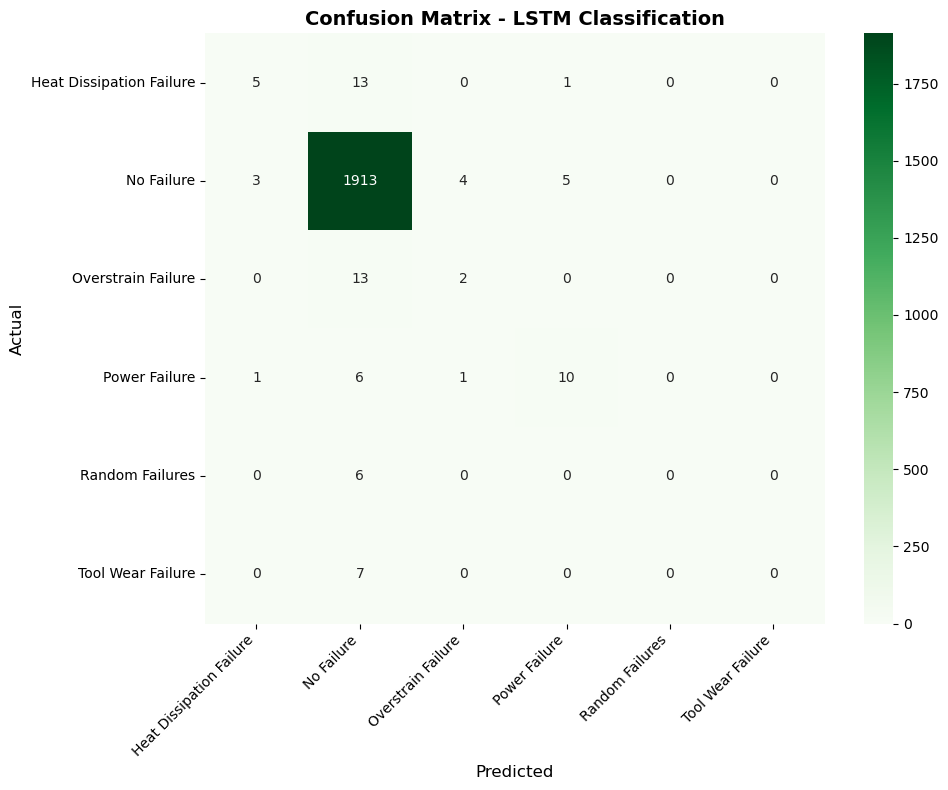

✓ Confusion matrix saved to artifacts\confusion_matrix_lstm.png


In [67]:
plt.figure(figsize=(10, 6))

fpr_lstm, tpr_lstm, _ = roc_curve(y_test_binary_lstm, y_pred_binary_lstm)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {roc_auc_lstm_clf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - LSTM Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'roc_curve_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved to {ARTIFACTS_DIR / 'roc_curve_lstm.png'}")

# %%
# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))

precision_lstm, recall_lstm, _ = precision_recall_curve(y_test_binary_lstm, y_pred_binary_lstm)
plt.plot(recall_lstm, precision_lstm, label=f'LSTM (AP = {pr_auc_lstm_clf:.3f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - LSTM Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'pr_curve_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ PR curve saved to {ARTIFACTS_DIR / 'pr_curve_lstm.png'}")

# Plot Confusion Matrix
cm_lstm_clf = confusion_matrix(y_test_seq_clf, y_pred_lstm_clf_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm_clf, annot=True, fmt='d', cmap='Greens',
            xticklabels=[failure_mapping_inv[i] for i in range(len(cm_lstm_clf))],
            yticklabels=[failure_mapping_inv[i] for i in range(len(cm_lstm_clf))])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - LSTM Classification', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'confusion_matrix_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved to {ARTIFACTS_DIR / 'confusion_matrix_lstm.png'}")

### Save LSTM classifier

In [68]:
lstm_clf_model.save(str(ARTIFACTS_DIR / 'lstm_classifier.h5'))
lstm_clf_model.save(str(ARTIFACTS_DIR / 'lstm_classifier.keras'))
print(f"\n✓ LSTM classifier saved to:")
print(f"  - {ARTIFACTS_DIR / 'lstm_classifier.h5'}")
print(f"  - {ARTIFACTS_DIR / 'lstm_classifier.keras'}")


✓ LSTM classifier saved to:
  - artifacts\lstm_classifier.h5
  - artifacts\lstm_classifier.keras


### 5.2 LSTM Regression (Time-Series Forecasting)

In [69]:
print(f"\n{'='*80}")
print("LSTM REGRESSION - SEQUENCE-BASED RUL FORECASTING")
print(f"{'='*80}")

# Build LSTM regression architecture
lstm_reg_model = keras.Sequential([
    layers.LSTM(64, activation='relu', return_sequences=True,
                input_shape=(WINDOW_SIZE, n_features)),
    layers.Dropout(0.3),
    layers.LSTM(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Single output for RUL
], name='LSTM_Regressor')

lstm_reg_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("\n" + "="*80)
print("LSTM Regression Architecture")
print("="*80)
lstm_reg_model.summary()

# %%
# Train LSTM regressor
print(f"\n{'='*80}")
print("Training LSTM Regressor...")
print(f"{'='*80}")

early_stop_reg = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_lstm_reg = lstm_reg_model.fit(
    X_train_seq_reg, y_train_seq_reg,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_reg],
    verbose=1
)

print("\n✓ Training completed")

# %%
# Predictions
y_pred_lstm_reg = lstm_reg_model.predict(X_test_seq_reg).flatten()

# %%
# Calculate regression metrics
print(f"\n{'='*80}")
print("LSTM Regression Metrics")
print(f"{'='*80}")

rmse_lstm_reg = np.sqrt(mean_squared_error(y_test_seq_reg, y_pred_lstm_reg))
mae_lstm_reg = mean_absolute_error(y_test_seq_reg, y_pred_lstm_reg)
mse_lstm_reg = mean_squared_error(y_test_seq_reg, y_pred_lstm_reg)
r2_lstm_reg = r2_score(y_test_seq_reg, y_pred_lstm_reg)

print(f"\nRMSE: {rmse_lstm_reg:.4f} days {'✓' if rmse_lstm_reg < 30 else '✗'}")
print(f"MAE: {mae_lstm_reg:.4f} days {'✓' if mae_lstm_reg < 20 else '✗'}")
print(f"MSE: {mse_lstm_reg:.4f}")
print(f"R²: {r2_lstm_reg:.4f}")

# Save metrics
lstm_reg_metrics_text = f"""LSTM Regression Metrics
{'='*50}

RMSE: {rmse_lstm_reg:.4f} days
MAE: {mae_lstm_reg:.4f} days
MSE: {mse_lstm_reg:.4f}
R²: {r2_lstm_reg:.4f}

Target Achievement:
- RMSE < 30 days: {'PASS' if rmse_lstm_reg < 30 else 'FAIL'}
- MAE < 20 days: {'PASS' if mae_lstm_reg < 20 else 'FAIL'}
"""

with open(ARTIFACTS_DIR / 'lstm_reg_metrics.txt', 'w') as f:
    f.write(lstm_reg_metrics_text)

print(f"\n✓ Metrics saved to {ARTIFACTS_DIR / 'lstm_reg_metrics.txt'}")


LSTM REGRESSION - SEQUENCE-BASED RUL FORECASTING

LSTM Regression Architecture


Model: "LSTM_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 10, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM Regressor...
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2851.1743 - mae: 40.3527 - val_loss: 651.2373 - val_mae: 20.2055
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2851.1743 - mae: 40.3527 - val_loss: 651.2373 - val_mae: 20.2055
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 890.2532 - mae: 23.8419 - val_loss: 724.8061 - val_mae: 22.0105
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 890.2532 - mae: 23.8419 - val_loss: 724.8061 - val_mae: 22.0105
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 777.7034 - mae: 22.0897 - val_loss: 872.6675 - val_mae: 24.8952
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 777.7034 - mae: 22.0897 - val_loss: 872.6675 - val_mae: 24.8952
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 659.9153 - mae: 20.1714 - val_loss: 790.8846 - val_mae: 24.1681
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 659.9153 - mae: 20.1714 - val_loss: 790.88

### Plot Predicted vs Actual

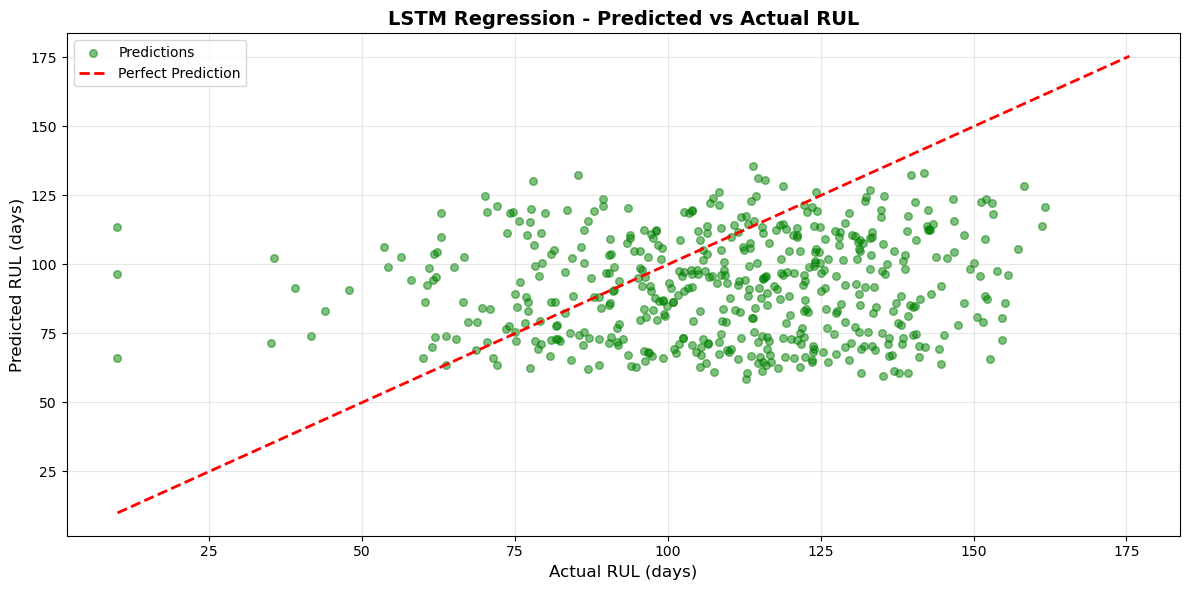

✓ Prediction plot saved to artifacts\predicted_vs_actual_lstm.png


In [70]:
plt.figure(figsize=(12, 6))

sample_size = min(500, len(y_test_seq_reg))
sample_indices = np.random.choice(len(y_test_seq_reg), sample_size, replace=False)

plt.scatter(y_test_seq_reg[sample_indices], y_pred_lstm_reg[sample_indices],
            alpha=0.5, s=30, label='Predictions', color='green')
plt.plot([y_test_seq_reg.min(), y_test_seq_reg.max()],
         [y_test_seq_reg.min(), y_test_seq_reg.max()],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual RUL (days)', fontsize=12)
plt.ylabel('Predicted RUL (days)', fontsize=12)
plt.title('LSTM Regression - Predicted vs Actual RUL', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'predicted_vs_actual_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Prediction plot saved to {ARTIFACTS_DIR / 'predicted_vs_actual_lstm.png'}")

### Save LSTM regressor

In [71]:
lstm_reg_model.save(str(ARTIFACTS_DIR / 'lstm_regressor.h5'))
lstm_reg_model.save(str(ARTIFACTS_DIR / 'lstm_regressor.keras'))
print(f"\n✓ LSTM regressor saved to:")
print(f"  - {ARTIFACTS_DIR / 'lstm_regressor.h5'}")
print(f"  - {ARTIFACTS_DIR / 'lstm_regressor.keras'}")


✓ LSTM regressor saved to:
  - artifacts\lstm_regressor.h5
  - artifacts\lstm_regressor.keras


### 6. Results Summary and Performance Comparison

In [72]:
print(f"\n{'='*80}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*80}")

# Create comparison table
results_data = {
    'Model': [
        'XGBoost Classification',
        'XGBoost Regression',
        'LSTM Classification',
        'LSTM Regression'
    ],
    'Task': [
        'Anomaly Detection',
        'RUL Forecasting',
        'Anomaly Detection',
        'RUL Forecasting'
    ],
    'ACC': [acc_xgb_clf, '-', acc_lstm_clf, '-'],
    'PREC': [prec_xgb_clf, '-', prec_lstm_clf, '-'],
    'REC': [rec_xgb_clf, '-', rec_lstm_clf, '-'],
    'F1': [f1_xgb_clf, '-', f1_lstm_clf, '-'],
    'ROC-AUC': [roc_auc_xgb_clf, '-', roc_auc_lstm_clf, '-'],
    'PR-AUC': [pr_auc_xgb_clf, '-', pr_auc_lstm_clf, '-'],
    'RMSE': ['-', rmse_xgb_reg, '-', rmse_lstm_reg],
    'MAE': ['-', mae_xgb_reg, '-', mae_lstm_reg],
    'MSE': ['-', mse_xgb_reg, '-', mse_lstm_reg]
}

results_df = pd.DataFrame(results_data)

print("\n" + "="*120)
print("MODEL PERFORMANCE COMPARISON")
print("="*120)
print(results_df.to_string(index=False))

# %%
# Target achievement analysis
print(f"\n{'='*80}")
print("TARGET ACHIEVEMENT ANALYSIS")
print(f"{'='*80}")

print("\n📊 Classification Models (Target: Recall > 70% AND Accuracy > 70%)")
print("-" * 80)

xgb_clf_pass = (rec_xgb_clf > 0.70) and (acc_xgb_clf > 0.70)
lstm_clf_pass = (rec_lstm_clf > 0.70) and (acc_lstm_clf > 0.70)

print(f"\nXGBoost Classification:")
print(f"  Recall: {rec_xgb_clf:.4f} {'✓' if rec_xgb_clf > 0.70 else '✗'}")
print(f"  Accuracy: {acc_xgb_clf:.4f} {'✓' if acc_xgb_clf > 0.70 else '✗'}")
print(f"  Overall: {'✓ PASS' if xgb_clf_pass else '✗ FAIL'}")

print(f"\nLSTM Classification:")
print(f"  Recall: {rec_lstm_clf:.4f} {'✓' if rec_lstm_clf > 0.70 else '✗'}")
print(f"  Accuracy: {acc_lstm_clf:.4f} {'✓' if acc_lstm_clf > 0.70 else '✗'}")
print(f"  Overall: {'✓ PASS' if lstm_clf_pass else '✗ FAIL'}")

print("\n\n📈 Regression Models (Target: MAE < 20 days)")
print("-" * 80)

xgb_reg_pass = mae_xgb_reg < 20
lstm_reg_pass = mae_lstm_reg < 20

print(f"\nXGBoost Regression:")
print(f"  MAE: {mae_xgb_reg:.4f} days {'✓' if xgb_reg_pass else '✗'}")
print(f"  Overall: {'✓ PASS' if xgb_reg_pass else '✗ FAIL'}")

print(f"\nLSTM Regression:")
print(f"  MAE: {mae_lstm_reg:.4f} days {'✓' if lstm_reg_pass else '✗'}")
print(f"  Overall: {'✓ PASS' if lstm_reg_pass else '✗ FAIL'}")


FINAL RESULTS SUMMARY

MODEL PERFORMANCE COMPARISON
                 Model              Task       ACC      PREC       REC        F1   ROC-AUC    PR-AUC      RMSE        MAE          MSE
XGBoost Classification Anomaly Detection     0.945  0.978242     0.945   0.96099  0.921477   0.99899         -          -            -
    XGBoost Regression   RUL Forecasting         -         -         -         -         -         -  5.522236   4.337039    30.495096
   LSTM Classification Anomaly Detection  0.969849  0.958216  0.969849  0.963238  0.942631  0.992928         -          -            -
       LSTM Regression   RUL Forecasting         -         -         -         -         -         -  35.98886  29.357852  1295.198031

TARGET ACHIEVEMENT ANALYSIS

📊 Classification Models (Target: Recall > 70% AND Accuracy > 70%)
--------------------------------------------------------------------------------

XGBoost Classification:
  Recall: 0.9450 ✓
  Accuracy: 0.9450 ✓
  Overall: ✓ PASS

LSTM Classi

### Recommendations

In [73]:
print(f"\n{'='*80}")
print("RECOMMENDATIONS")
print(f"{'='*80}")

print("\n🎯 Best Model for Anomaly Detection:")
if acc_lstm_clf > acc_xgb_clf:
    print(f"  ➤ LSTM Classification (Accuracy: {acc_lstm_clf:.4f}, Recall: {rec_lstm_clf:.4f})")
    print(f"    Reason: Better accuracy and recall, captures temporal patterns")
else:
    print(f"  ➤ XGBoost Classification (Accuracy: {acc_xgb_clf:.4f}, Recall: {rec_xgb_clf:.4f})")
    print(f"    Reason: Superior performance, faster inference, handles imbalance well")

print("\n📊 Best Model for RUL Forecasting:")
if mae_lstm_reg < mae_xgb_reg:
    print(f"  ➤ LSTM Regression (MAE: {mae_lstm_reg:.4f} days, RMSE: {rmse_lstm_reg:.4f} days)")
    print(f"    Reason: Lower error, better at capturing sequential dependencies")
else:
    print(f"  ➤ XGBoost Regression (MAE: {mae_xgb_reg:.4f} days, RMSE: {rmse_xgb_reg:.4f} days)")
    print(f"    Reason: More accurate predictions, robust to noise")

print("\n🚀 Recommended for Agentic AI Copilot Integration:")
print("  ➤ Hybrid Approach:")
print("    - Use XGBoost Classification for real-time anomaly detection (fast inference)")
print("    - Use LSTM Regression for long-term RUL forecasting (temporal patterns)")
print("    - Combine predictions for comprehensive maintenance recommendations")

print("\n💡 Additional Recommendations:")
print("  • Implement ensemble methods combining XGBoost + LSTM")
print("  • Deploy XGBoost for edge devices (lower latency)")
print("  • Use LSTM for batch processing and trend analysis")
print("  • Retrain models monthly with new operational data")
print("  • Monitor model drift and implement alerting thresholds")


RECOMMENDATIONS

🎯 Best Model for Anomaly Detection:
  ➤ LSTM Classification (Accuracy: 0.9698, Recall: 0.9698)
    Reason: Better accuracy and recall, captures temporal patterns

📊 Best Model for RUL Forecasting:
  ➤ XGBoost Regression (MAE: 4.3370 days, RMSE: 5.5222 days)
    Reason: More accurate predictions, robust to noise

🚀 Recommended for Agentic AI Copilot Integration:
  ➤ Hybrid Approach:
    - Use XGBoost Classification for real-time anomaly detection (fast inference)
    - Use LSTM Regression for long-term RUL forecasting (temporal patterns)
    - Combine predictions for comprehensive maintenance recommendations

💡 Additional Recommendations:
  • Implement ensemble methods combining XGBoost + LSTM
  • Deploy XGBoost for edge devices (lower latency)
  • Use LSTM for batch processing and trend analysis
  • Retrain models monthly with new operational data
  • Monitor model drift and implement alerting thresholds


### Verify all artifacts

In [74]:
print(f"\n{'='*80}")
print("ARTIFACT VERIFICATION")
print(f"{'='*80}")

expected_artifacts = [
    'label_mappings.joblib',
    'scaler.joblib',
    'xgb_classifier.json',
    'xgb_regressor.json',
    'lstm_classifier.h5',
    'lstm_regressor.h5',
    'xgb_clf_metrics.txt',
    'xgb_reg_metrics.txt',
    'lstm_clf_metrics.txt',
    'lstm_reg_metrics.txt',
    'roc_curve_xgb.png',
    'pr_curve_xgb.png',
    'confusion_matrix_xgb.png',
    'predicted_vs_actual_xgb.png',
    'roc_curve_lstm.png',
    'pr_curve_lstm.png',
    'confusion_matrix_lstm.png',
    'predicted_vs_actual_lstm.png'
]

print("\nChecking artifacts...")
for artifact in expected_artifacts:
    path = ARTIFACTS_DIR / artifact
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {artifact}")

print(f"\n✓ All artifacts saved successfully in '{ARTIFACTS_DIR}/'")


ARTIFACT VERIFICATION

Checking artifacts...
  ✓ label_mappings.joblib
  ✓ scaler.joblib
  ✓ xgb_classifier.json
  ✓ xgb_regressor.json
  ✓ lstm_classifier.h5
  ✓ lstm_regressor.h5
  ✓ xgb_clf_metrics.txt
  ✓ xgb_reg_metrics.txt
  ✓ lstm_clf_metrics.txt
  ✓ lstm_reg_metrics.txt
  ✓ roc_curve_xgb.png
  ✓ pr_curve_xgb.png
  ✓ confusion_matrix_xgb.png
  ✓ predicted_vs_actual_xgb.png
  ✓ roc_curve_lstm.png
  ✓ pr_curve_lstm.png
  ✓ confusion_matrix_lstm.png
  ✓ predicted_vs_actual_lstm.png

✓ All artifacts saved successfully in 'artifacts/'


### 8. Inference and Maintenance Recommendation Generation

In [75]:
print(f"\n{'='*80}")
print("INFERENCE PIPELINE")
print(f"{'='*80}")

# Load saved artifacts
print("\nLoading saved artifacts...")
label_mappings_loaded = joblib.load(ARTIFACTS_DIR / 'label_mappings.joblib')
scaler_loaded = joblib.load(ARTIFACTS_DIR / 'scaler.joblib')

xgb_clf_loaded = xgb.XGBClassifier()
xgb_clf_loaded.load_model(str(ARTIFACTS_DIR / 'xgb_classifier.json'))

xgb_reg_loaded = xgb.XGBRegressor()
xgb_reg_loaded.load_model(str(ARTIFACTS_DIR / 'xgb_regressor.json'))

print("✓ All artifacts loaded successfully")

# %%
# Prepare inference data (use test set as example)
print(f"\n{'='*80}")
print("RUNNING INFERENCE ON TEST DATA")
print(f"{'='*80}")

# Take sample from test set
n_inference_samples = min(100, len(X_test))
inference_indices = np.random.choice(len(X_test), n_inference_samples, replace=False)

X_inference = X_test.iloc[inference_indices].copy()
product_ids_inference = df.iloc[X_test.index[inference_indices]]['product_id'].values

# Preprocess inference data (same steps as training)
X_inference_num = X_inference[NUMERICAL_FEATURES].copy()
X_inference_cat = X_inference[[CATEGORICAL_FEATURE]].copy()

X_inference_num_scaled = scaler_loaded.transform(X_inference_num)
X_inference_processed = np.hstack([X_inference_num_scaled, X_inference_cat.values])

print(f"\nInference samples: {n_inference_samples}")

# %%
# Run inference
print("\nRunning classification inference...")
failure_predictions = xgb_clf_loaded.predict(X_inference_processed)
failure_proba = xgb_clf_loaded.predict_proba(X_inference_processed)

# Get corresponding data for regression
inference_df_indices = X_test.index[inference_indices]
inference_df_data = df_sorted.loc[df_sorted.index.isin(inference_df_indices)]

# For regression, we need lag features
if len(inference_df_data) > 0:
    X_inference_reg = inference_df_data[reg_features].values
    X_inference_reg_scaled = scaler_reg.transform(X_inference_reg)
    
    print("Running regression inference...")
    rul_predictions = xgb_reg_loaded.predict(X_inference_reg_scaled)
else:
    # Fallback: use mean RUL
    rul_predictions = np.full(n_inference_samples, df_sorted['rul_proxy'].mean())

# Ensure arrays are same length
min_len = min(len(product_ids_inference), len(failure_predictions), len(rul_predictions))
product_ids_inference = product_ids_inference[:min_len]
failure_predictions = failure_predictions[:min_len]
rul_predictions = rul_predictions[:min_len]



INFERENCE PIPELINE

Loading saved artifacts...
✓ All artifacts loaded successfully

RUNNING INFERENCE ON TEST DATA

Inference samples: 100

Running classification inference...
Running regression inference...
✓ All artifacts loaded successfully

RUNNING INFERENCE ON TEST DATA

Inference samples: 100

Running classification inference...
Running regression inference...


### Generate recommendations

In [76]:
print(f"\n{'='*80}")
print("GENERATING MAINTENANCE RECOMMENDATIONS")
print(f"{'='*80}")

recommendations = []

for i in range(min_len):
    product_id = product_ids_inference[i]
    failure_type_encoded = failure_predictions[i]
    forecasted_days = int(np.round(rul_predictions[i]))
    
    # Convert encoded failure type back to string
    failure_type_str = label_mappings_loaded['failure_mapping_inv'][failure_type_encoded]
    
    # Generate recommendation text
    if failure_type_str == 'No Failure':
        recommendation = f"Machine {product_id} is operating normally. Next inspection in {forecasted_days} days."
    else:
        recommendation = f"Machine {product_id} in {forecasted_days} days needs maintenance because of {failure_type_str}"
    
    recommendations.append({
        'product_id': product_id,
        'forecasted_days': forecasted_days,
        'predicted_failure_type': failure_type_str,
        'failure_probability': float(np.max(failure_proba[i])),
        'recommendation_text': recommendation
    })

# Create recommendations dataframe
recommendations_df = pd.DataFrame(recommendations)

print(f"\n✓ Generated {len(recommendations)} recommendations")
print("\nSample Recommendations:")
print(recommendations_df.head(10).to_string(index=False))

# %%
# Save recommendations to CSV
recommendations_csv_path = ARTIFACTS_DIR / 'inference_recommendations.csv'
recommendations_df.to_csv(recommendations_csv_path, index=False)

print(f"\n✓ Recommendations saved to {recommendations_csv_path}")

# %%
# Display summary statistics
print(f"\n{'='*80}")
print("INFERENCE SUMMARY STATISTICS")
print(f"{'='*80}")

print(f"\nPredicted Failure Type Distribution:")
print(recommendations_df['predicted_failure_type'].value_counts())

print(f"\nForecasted Days Statistics:")
print(recommendations_df['forecasted_days'].describe())

print(f"\nCritical Machines (forecasted_days < 30):")
critical_machines = recommendations_df[recommendations_df['forecasted_days'] < 30]
print(f"  Count: {len(critical_machines)}")
if len(critical_machines) > 0:
    print("\n  Details:")
    print(critical_machines[['product_id', 'forecasted_days', 'predicted_failure_type']].to_string(index=False))


GENERATING MAINTENANCE RECOMMENDATIONS

✓ Generated 100 recommendations

Sample Recommendations:
product_id  forecasted_days predicted_failure_type  failure_probability                                                recommendation_text
    L54625              126             No Failure             0.616953 Machine L54625 is operating normally. Next inspection in 126 days.
    H34422              112             No Failure             0.999868 Machine H34422 is operating normally. Next inspection in 112 days.
    L52688              113             No Failure             0.613321 Machine L52688 is operating normally. Next inspection in 113 days.
    M19716              123             No Failure             0.999962 Machine M19716 is operating normally. Next inspection in 123 days.
    L49326               91             No Failure             0.987656  Machine L49326 is operating normally. Next inspection in 91 days.
    L55452              107             No Failure             0.996